In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import csv
import ast

import urllib.request as urlrequest
from collections import Counter
from goose3 import Goose
from goose3.network import NetworkError
from bertopic import BERTopic
from scipy.cluster import hierarchy as sch
from sklearn.feature_extraction.text import CountVectorizer
from urllib.parse import urlparse
from scipy.spatial.distance import pdist, squareform
import umap
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cdist
import torch

import re
from collections import defaultdict


In [25]:
!pip install waybackpy

In [32]:
from goose3 import Goose
from waybackpy import WaybackMachineCDXServerAPI

# Goose instance
g = Goose({
    "browser_user_agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15)",
    "http_timeout": 15
})

def simplify(domain):
    return domain.replace("www.", "").split(".")[0] if domain else ""

def fetch_from_wayback(url, user_agent="Mozilla/5.0 (Windows NT 5.1; rv:40.0) Gecko/20100101 Firefox/40.0"):
    try:
        cdx = WaybackMachineCDXServerAPI(url, user_agent)
        archive_url = cdx.oldest().archive_url
        time.sleep(0.25)
        article = g.extract(url=archive_url)
        return article, archive_url
    except Exception as e:
        return None, None

def goose_it(df):
    for i in df.index:
        try:
            url = df.loc[i, 'SOURCEURL']
            article = g.extract(url=url)
        except NetworkError:
            article, archive_url = fetch_from_wayback(url)
            if article is None:
                df.drop(index=i, inplace=True)
                continue
        except Exception as e:
            df.drop(index=i, inplace=True)
            continue

        try:
            df.at[i, 'domain'] = article.domain
            df.at[i, 'target'] = simplify(article.domain)
            df.at[i, 'title'] = article.title
            df.at[i, 'text'] = article.cleaned_text
            df.at[i, 'description'] = article.opengraph.get('description', '')
        except Exception as e:
            df.drop(index=i, inplace=True)

    return df

In [13]:
d_20181127 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/nela/20181127.export.CSV',sep='\t',header=None)
d_20200611 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/nela/20200611.export.CSV',sep='\t',header=None)
d_20211124 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/nela/20211124.export.CSV',sep='\t',header=None)
d_20220206 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/nela/20220206.export.CSV',sep='\t',header=None)
d_20220928 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/nela/20220928.export.CSV',sep='\t',header=None)


/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (11,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (14,26,27,28) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [15]:
d_20181127 = d_20181127.rename(columns=map)
d_20200611 = d_20200611.rename(columns=map)
d_20211124 = d_20211124.rename(columns=map)
d_20220206 = d_20220206.rename(columns=map)
d_20220928 = d_20220928.rename(columns=map)

In [21]:
d_20181127 = clean(d_20181127)
d_20200611 = clean(d_20200611)
d_20211124 = clean(d_20211124)
d_20220206 = clean(d_20220206)
d_20220928 = clean(d_20220928)

In [ ]:
alldf = pd.concat([d_20181127, d_20200611, d_20211124, d_20220206, d_20220928])



In [33]:
alldf = goose_it(alldf)

KeyboardInterrupt: 

In [7]:
#d_200908 = pd.read_csv('200908.CSV',sep='\t',header=None)
#d_20140523 = pd.read_csv('20140523.export.CSV',sep='\t',header=None)
d_20140521 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140521.export.CSV',sep='\t',header=None)
d_20140522 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140522.export.CSV',sep='\t',header=None)
d_20140523 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140523.export.CSV',sep='\t',header=None)
d_20140524 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140524.export.CSV',sep='\t',header=None)
d_20140525 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140525.export.CSV',sep='\t',header=None)
d_20140526 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140526.export.CSV',sep='\t',header=None)
d_20140527 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140527.export.CSV',sep='\t',header=None)
d_20140528 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140528.export.CSV',sep='\t',header=None)

g_20140521 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/goose_20140521.export.CSV')
g_20140522 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/goose_20140522.export.CSV')
g_20140523 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/goose_20140523.export.CSV')
g_20140524 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/l_CA.csv')
g_20140525 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/goose_20140525.export.CSV')
g_20140526 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/goose_20140526.export.CSV')
g_20140527 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/goose_20140527.export.CSV')
g_20140528 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/goose_20140528.export.CSV')

#fb_20140521 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140521.export.CSV',sep='\t',header=None)
#fb_20140522 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140522.export.CSV',sep='\t',header=None)
#fb_20140523 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140523.export.CSV',sep='\t',header=None)
#fb_20140524 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140524.export.CSV',sep='\t',header=None)
#fb_20140525 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140525.export.CSV',sep='\t',header=None)
#fb_20140526 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140526.export.CSV',sep='\t',header=None)
#fb_20140527 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140527.export.CSV',sep='\t',header=None)
#fb_20140528 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/20140528.export.CSV',sep='\t',header=None)

hate_20140521 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140521.export.CSV')
hate_20140522 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140522.export.CSV')
hate_20140523 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140523.export.CSV')
hate_20140524 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140524.export.CSV')
hate_20140525 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140525.export.CSV')
hate_20140526 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140526.export.CSV')
hate_20140527 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140527.export.CSV')
hate_20140528 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/hategoose_20140528.export.CSV')

twit_20140521 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140521.export.CSV')
twit_20140522 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140522.export.CSV')
twit_20140523 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140523.export.CSV')
twit_20140524 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140524.export.CSV')
twit_20140525 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140525.export.CSV')
twit_20140526 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140526.export.CSV')
twit_20140527 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140527.export.CSV')
twit_20140528 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CA/twittergoose_20140528.export.CSV')
##elliot rodgers CA

/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,9,11,14) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,9,10,11,14) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,9,10,11,12,13,14,19) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,9,11) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(c

In [ ]:
d_20250529 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250529.export.CSV',sep='\t',header=None)
d_20250530 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250530.export.CSV',sep='\t',header=None)
d_20250531 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250531.export.CSV',sep='\t',header=None)
d_20250601 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250601.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250602.export.CSV',sep='\t',header=None)
d_20250603 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250603.export.CSV',sep='\t',header=None)
d_20250604 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250604.export.CSV',sep='\t',header=None)
d_20250605 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250605.export.CSV',sep='\t',header=None)
d_20250606 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/20250605.export.CSV',sep='\t',header=None)

g_20250529 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250529.export.CSV')
g_20250530 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250530.export.CSV')
g_20250531 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250531.export.CSV')
g_20250601 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250601.export.CSV')
g_20250602 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250602.export.CSV')
g_20250603 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250603.export.CSV')
g_20250604 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250604.export.CSV')
g_20250605 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250605.export.CSV')
g_20250606 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_CO/goose_20250606.export.CSV')



In [50]:
g_20250529 = add_hurtlex_columns(g_20250529)
g_20250530 = add_hurtlex_columns(g_20250530)
g_20250531 = add_hurtlex_columns(g_20250531)
g_20250601 = add_hurtlex_columns(g_20250601)
g_20250602 = add_hurtlex_columns(g_20250602)
g_20250603 = add_hurtlex_columns(g_20250603)
g_20250604 = add_hurtlex_columns(g_20250604)
g_20250605 = add_hurtlex_columns(g_20250605)
g_20250606 = add_hurtlex_columns(g_20250606)

In [ ]:

d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('20160612.export.CSV',sep='\t',header=None)

##orlando night club FL
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('20170812.export.CSV',sep='\t',header=None)

##charlottesville VA
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)
d_20171031 = pd.read_csv('20171031.export.CSV',sep='\t',header=None)

##truck attack NY
#d_20180423 = pd.read_csv('20180423.export.CSV',sep='\t',header=None)
##TORONTO skip for now
#d_20200526 = pd.read_csv('20200526.export.CSV',sep='\t',header=None)
##george floyd MN
#d_20250101 = pd.read_csv('20250101.export.CSV',sep='\t',header=None)
##truck attack neworleans TN
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)
d_20250602 = pd.read_csv('20250602.export.CSV',sep='\t',header=None)

#anti israel CO

/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,9,11,14) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,11,14,19,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (26,27,28) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [2]:
nela = pd.read_csv('nela_sample.csv')

In [54]:
d_20160608 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160608.export.CSV',sep='\t',header=None)
d_20160609 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160609.export.CSV',sep='\t',header=None)
d_20160610 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160610.export.CSV',sep='\t',header=None)
d_20160611 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160611.export.CSV',sep='\t',header=None)
d_20160612 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160612.export.CSV',sep='\t',header=None)
d_20160613 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160613.export.CSV',sep='\t',header=None)
d_20160614 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160614.export.CSV',sep='\t',header=None)
d_20160615 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/20160615.export.CSV',sep='\t',header=None)

g_20160608 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/goose_20160608.export.CSV')
g_20160609 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/goose_20160609.export.CSV')
g_20160610 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/goose_20160610.export.CSV')
g_20160611 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/goose_20160611.export.CSV')
g_20160612 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/l_FL.csv')
g_20160613 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/goose_20160613.export.CSV')
g_20160614 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/goose_20160614.export.CSV')
g_20160615 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_FL/goose_20160615.export.CSV')

/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (26,27,28) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (24,26,27,28) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [58]:
d_20170808 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170808.export.CSV',sep='\t',header=None)
d_20170809 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170809.export.CSV',sep='\t',header=None)
d_20170810 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170810.export.CSV',sep='\t',header=None)
d_20170811 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170811.export.CSV',sep='\t',header=None)
d_20170812 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170812.export.CSV',sep='\t',header=None)
d_20170813 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170813.export.CSV',sep='\t',header=None)
d_20170814 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170814.export.CSV',sep='\t',header=None)
d_20170815 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/20170815.export.CSV',sep='\t',header=None)

g_20170808 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/goose_20170808.export.CSV')
g_20170809 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/goose_20170809.export.CSV')
g_20170810 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/goose_20170810.export.CSV')
g_20170811 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/goose_20170811.export.CSV')
g_20170812 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/l_VA.csv')
g_20170813 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/goose_20170813.export.CSV')
g_20170814 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/goose_20170814.export.CSV')
g_20170815 = pd.read_csv('/Users/emilylugos/Desktop/Desktop - Emily’s MacBook Pro/summer_2025/research/HSMS_LUGOS/goose_VA/goose_20170815.export.CSV')

/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (26,27,28) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,10,11,19,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (8,11,14,19,24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/emilylugos/opt/anaconda3/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3444: DtypeWarning: Columns (24) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, sel

In [14]:
map = {
    0: "GlobalEventID", 
    1: "date", 
    2: "MonthYear", 
    3: "Year", 
    4: "FractionDate", 
    5: "Actor1Code", 
    6: "Actor1Name", 
    7: "Actor1CountryCode", 
    8: "Actor1KnownGroupCode", 
    9: "Actor1EthnicCode",
    10: "Actor1Religion1Code", 
    11: "Actor1Religion2Code", 
    12: "Actor1Type1Code", 
    13: "Actor1Type2Code",
    14: "Actor1Type3Code", 
    15: "Actor2Code", 
    16: "Actor2Name", 
    17: "Actor2CountryCode", 
    18: "Actor2KnownGroupCode", 
    19: "Actor2EthnicCode",
    20: "Actor2Religion1Code", 
    21: "Actor2Religion2Code", 
    22: "Actor2Type1Code", 
    23: "Actor2Type2Code", 
    24: "Actor2Type3Code", 
    25: "IsRootEvent", 
    26: "EventCode", 
    27: "EventBaseCode", 
    28: "EventRootCode", 
    29: "QuadClass",
    30: "GoldsteinScale", 
    31: "NumMentions", 
    32: "NumSources", 
    33: "NumArticles", 
    34: "AvgTone", 
    35: "Actor1Geo_Type", 
    36: "Actor1Geo_Fullname", 
    37: "Actor1Geo_CountryCode", 
    38: "Actor1Geo_ADM1Code", 
    39: "Actor1Geo_Lat",
    40: "Actor1Geo_Long", 
    41: "Actor1Geo_FeatureID", 
    42: "Actor2Geo_Type", 
    43: "Actor2Geo_Fullname", 
    44: "Actor2Geo_CountryCode", 
    45: "Actor2Geo_ADM1Code", 
    46: "Actor2Geo_Lat",
    47: "Actor2Geo_Long",
    48: "Actor2Geo_FeatureID", 
    49: "ActionGeo_Type", 
    50: "ActionGeo_Fullname", 
    51: "ActionGeo_CountryCode", 
    52: "ActionGeo_ADM1Code", 
    53: "ActionGeo_Lat", 
    54: "ActionGeo_Long", 
    55: "ActionGeo_FeatureID",
    56: "DATEADDED", 
    57: "SOURCEURL"
}

In [20]:
def clean(df):
    df = df.drop(columns=[
        'MonthYear', 'FractionDate','Actor1Code', 'Actor1Name','Actor1CountryCode',
        'Actor1KnownGroupCode','Actor1EthnicCode', 'Actor1Religion1Code','Actor1Religion2Code',
        'Actor1Type1Code','Actor1Type2Code','Actor1Type3Code','Actor2Code', 'Actor2Name',
        'Actor2CountryCode', 'Actor2KnownGroupCode','Actor2EthnicCode', 'Actor2Religion1Code',
        'Actor2Religion2Code', 'Actor2Type1Code','Actor2Type2Code','Actor2Type3Code',
        'Actor1Geo_Type', 'Actor1Geo_Fullname','Actor1Geo_ADM1Code', 'Actor1Geo_Lat',
        'Actor1Geo_Long', 'Actor1Geo_FeatureID', 'Actor2Geo_Type', 'Actor2Geo_Fullname',
        'Actor2Geo_ADM1Code', 'Actor2Geo_Lat','Actor2Geo_Long','Actor2Geo_FeatureID'
    ], errors='ignore')
    return df

In [36]:
def plot_df_lengths_with_conservative(d_list, d_names, g_list, g_names):
    # Extract dates (same for both sets)
    dates = [name.split("_")[1] for name in d_names]
    assert dates == [name.split("_")[1] for name in g_names], "Dates in d_ and g_ must match"

    # Row counts
    d_lengths = [len(df) for df in d_list]
    g_lengths = [len(df) for df in g_list]

    # Conservative counts
    conservative_counts = []
    for df in g_list:
        total = 0
        for val in df["hurtlex_level_counts"]:
            if isinstance(val, str):
                try:
                    val = ast.literal_eval(val)
                except Exception:
                    val = {}
            if isinstance(val, dict):
                total += val.get("conservative", 0)
        conservative_counts.append(total)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(dates, d_lengths, marker='o', label='d_ row count')
    plt.plot(dates, g_lengths, marker='s', label='g_ row count')
    plt.plot(dates, conservative_counts, marker='^', linestyle='--', color='red', label='g_ conservative count')

    plt.title("Row Counts and HurtLex 'Conservative' Counts by Date")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [15]:
d_20140524 = clean(d_20140524, 'CA')
d_20160612 =clean(d_20160612, 'FL')
d_20170812 = clean(d_20170812, 'VA')
d_20171031 = clean(d_20171031, 'NY')
d_20250602 = clean(d_20250602, 'CO')

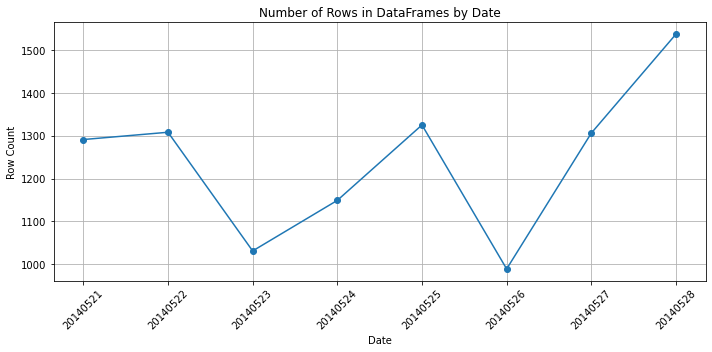

In [33]:
d_20140521 = clean(d_20140521, 'CA')
d_20140522 = clean(d_20140522, 'CA')
d_20140523 = clean(d_20140523, 'CA')
d_20140524 = clean(d_20140524, 'CA')
d_20140525 = clean(d_20140525, 'CA')
d_20140526 = clean(d_20140526, 'CA')
d_20140527 = clean(d_20140527, 'CA')
d_20140528 = clean(d_20140528, 'CA')

raw_dfs = [
    d_20140521,
    d_20140522,
    d_20140523,
    d_20140524,
    d_20140525,
    d_20140526,
    d_20140527,
    d_20140528
]

cleaned_dfs = [clean(df, 'CA') for df in raw_dfs]

def plot_df_lengths(df_list, df_names):
    # Extract dates from names and calculate lengths
    dates = [name.split("_")[1] for name in df_names]
    lengths = [len(df) for df in df_list]

    # Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(dates, lengths, marker='o')
    plt.title("Number of Rows in DataFrames by Date")
    plt.xlabel("Date")
    plt.ylabel("Row Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Cleaned dataframes
df_list = cleaned_dfs

# Corresponding variable names
df_names = [
    "d_20140521",
    "d_20140522",
    "d_20140523",
    "d_20140524",
    "d_20140525",
    "d_20140526",
    "d_20140527",
    "d_20140528"
]

# Call the function
plot_df_lengths(df_list, df_names)

In [11]:
def sort_ratio(df):
    # Ensure class_ratio column is a dictionary
    df = df.drop_duplicates(subset="text", keep="first").reset_index(drop=True)

    df["class_ratio"] = df["class_ratio"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

    # Find the highest class ID present in any row
    max_class = max(
        (max(ratio.keys()) for ratio in df["class_ratio"] if isinstance(ratio, dict) and ratio),
        default=0
    )

    # Create a new column for that max class's ratio
    df["max_class_ratio"] = df["class_ratio"].apply(lambda r: r.get(max_class, 0.0))

    # Sort by that column descending
    df_sorted = df.sort_values(by="max_class_ratio", ascending=False)

    return df_sorted

In [22]:
hate_20140521 = sort_ratio(hate_20140521)
hate_20140522 = sort_ratio(hate_20140522)
hate_20140523 = sort_ratio(hate_20140523)
hate_20140524 = sort_ratio(hate_20140524)
hate_20140525 = sort_ratio(hate_20140525)
hate_20140526 = sort_ratio(hate_20140526)
hate_20140527 = sort_ratio(hate_20140527)
hate_20140528 = sort_ratio(hate_20140528)

twit_20140521 = sort_ratio(twit_20140521)
twit_20140522 = sort_ratio(twit_20140521)
twit_20140523 = sort_ratio(twit_20140521)
twit_20140524 = sort_ratio(twit_20140521)
twit_20140525 = sort_ratio(twit_20140521)
twit_20140526 = sort_ratio(twit_20140521)
twit_20140527 = sort_ratio(twit_20140521)
twit_20140528 = sort_ratio(twit_20140521)

In [17]:
hurtlex_df = pd.read_csv("hurtlex_EN.tsv", sep="\t", header=None, comment="#")
hurtlex_df.columns = ["id", "pos", "category", "stereotype", "lemma", "level"]

lemma_to_category = defaultdict(list)
lemma_to_level = defaultdict(list)

for _, row in hurtlex_df.iterrows():
    lemma = row["lemma"].lower()
    lemma_to_category[lemma].append(row["category"])
    lemma_to_level[lemma].append(row["level"])

In [18]:
def add_hurtlex_columns(df):
    def analyze(text):
        category_counts = defaultdict(int)
        level_counts = defaultdict(int)
        tokens = re.findall(r"\b\w+\b", str(text).lower())
        for token in tokens:
            for category in lemma_to_category.get(token, []):
                category_counts[category] += 1
            for level in lemma_to_level.get(token, []):
                level_counts[level] += 1
        return dict(category_counts), dict(level_counts)

    df["hurtlex_category_counts"], df["hurtlex_level_counts"] = zip(
        *df["text"].map(analyze)
    )
    return df

In [19]:
g_20140521 = add_hurtlex_columns(g_20140521)
g_20140522 = add_hurtlex_columns(g_20140522)
g_20140523 = add_hurtlex_columns(g_20140523)
g_20140524 = add_hurtlex_columns(g_20140524)
g_20140525 = add_hurtlex_columns(g_20140525)
g_20140526 = add_hurtlex_columns(g_20140526)
g_20140527 = add_hurtlex_columns(g_20140527)
g_20140528 = add_hurtlex_columns(g_20140528)

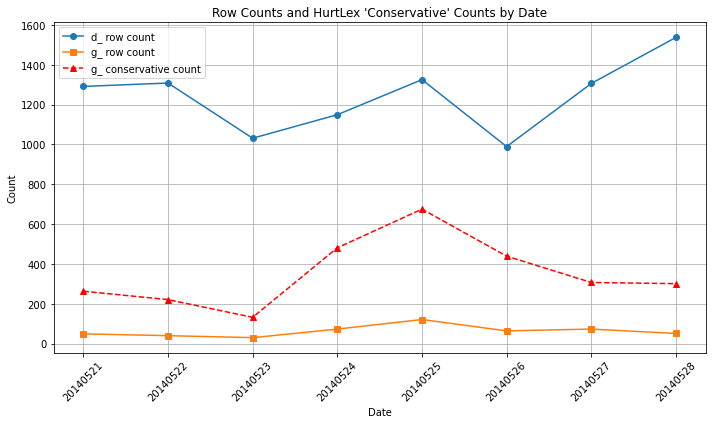

In [37]:
d_list = [d_20140521, d_20140522, d_20140523, d_20140524, d_20140525, d_20140526, d_20140527, d_20140528]
g_list = [g_20140521, g_20140522, g_20140523, g_20140524, g_20140525, g_20140526, g_20140527, g_20140528]

d_names = ["d_20140521", "d_20140522", "d_20140523", "d_20140524", "d_20140525", "d_20140526", "d_20140527", "d_20140528"]
g_names = ["g_20140521", "g_20140522", "g_20140523", "g_20140524", "g_20140525", "g_20140526", "g_20140527", "g_20140528"]

# Plot
plot_df_lengths_with_conservative(d_list, d_names, g_list, g_names)

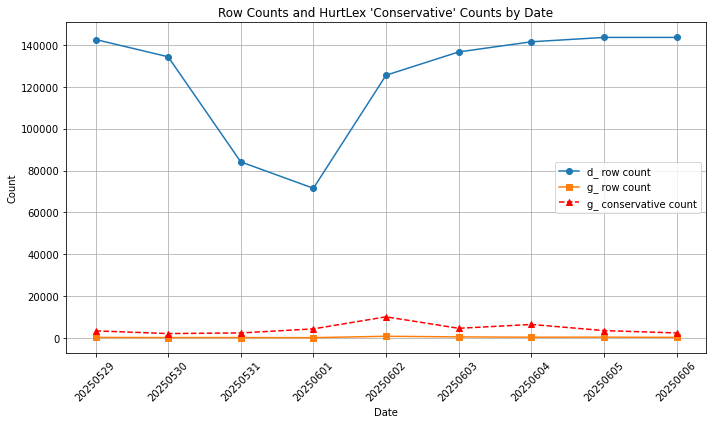

In [51]:
# Datasets (original)
d_list = [
    d_20250529, d_20250530, d_20250531, d_20250601, d_20250602,
    d_20250603, d_20250604, d_20250605, d_20250606
]

d_names = [
    "d_20250529", "d_20250530", "d_20250531", "d_20250601", "d_20250602",
    "d_20250603", "d_20250604", "d_20250605", "d_20250606"
]

# Goose-processed datasets
g_list = [
    g_20250529, g_20250530, g_20250531, g_20250601, g_20250602,
    g_20250603, g_20250604, g_20250605, g_20250606
]

g_names = [
    "g_20250529", "g_20250530", "g_20250531", "g_20250601", "g_20250602",
    "g_20250603", "g_20250604", "g_20250605", "g_20250606"
]

plot_df_lengths_with_conservative(d_list, d_names, g_list, g_names)

In [56]:
goosed_df = [add_hurtlex_columns(df)for df in g_list]

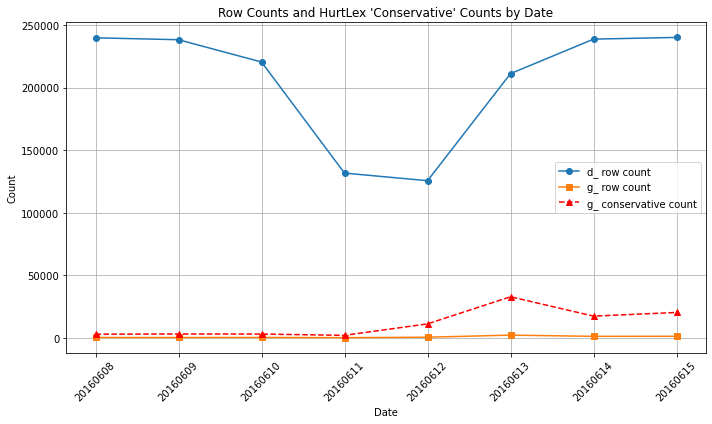

In [57]:
d_list = [
    d_20160608, d_20160609, d_20160610, d_20160611,
    d_20160612, d_20160613, d_20160614, d_20160615
]

d_names = [
    "d_20160608", "d_20160609", "d_20160610", "d_20160611",
    "d_20160612", "d_20160613", "d_20160614", "d_20160615"
]

g_list = [
    g_20160608, g_20160609, g_20160610, g_20160611,
    g_20160612, g_20160613, g_20160614, g_20160615
]

g_names = [
    "g_20160608", "g_20160609", "g_20160610", "g_20160611",
    "g_20160612", "g_20160613", "g_20160614", "g_20160615"
]

plot_df_lengths_with_conservative(d_list, d_names, g_list, g_names)

In [44]:
def plot_non_binary_and_conservative_counts(hate_dfs, hate_names, twit_dfs, twit_names, g_dfs, g_names):
    # Extract and validate dates
    dates = [name.split("_")[1] for name in hate_names]
    assert dates == [name.split("_")[1] for name in twit_names] == [name.split("_")[1] for name in g_names], "Date mismatch across lists"

    def count_non_binary(df):
        return df['max_class_ratio'].apply(lambda x: x not in [0, 1]).sum()

    def conservative_count(df):
        total = 0
        for val in df["hurtlex_level_counts"]:
            if isinstance(val, str):
                try:
                    val = ast.literal_eval(val)
                except:
                    val = {}
            if isinstance(val, dict):
                total += val.get("conservative", 0)
        return total

    # Collect counts
    hate_non_binary = [count_non_binary(df) for df in hate_dfs]
    twit_non_binary = [count_non_binary(df) for df in twit_dfs]
    #fb_non_binary   = [count_non_binary(df) for df in fb_dfs]

    conservative_counts = [conservative_count(df) for df in g_dfs]

    # Plotting
    plt.figure(figsize=(12, 6))

    # Non-binary class ratios
    plt.plot(dates, hate_non_binary, marker='o', label='Hate - Non-Binary')
    plt.plot(dates, twit_non_binary, marker='s', label='Twit - Non-Binary')
    #plt.plot(dates, fb_non_binary, marker='^', label='FB - Non-Binary')

    # Conservative counts (from g_* only)
    plt.plot(dates, conservative_counts, marker='x', linestyle='--', label='Conservative Count (g_*)')

    # Styling
    plt.title("Non-Binary max_class_ratio & Conservative Counts Over Time")
    plt.xlabel("Date")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

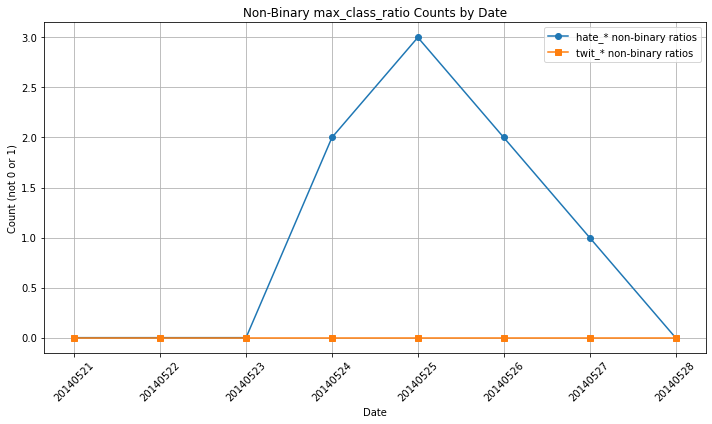

In [40]:
hate_dfs = [
    hate_20140521, hate_20140522, hate_20140523, hate_20140524,
    hate_20140525, hate_20140526, hate_20140527, hate_20140528
]
hate_names = [
    "hate_20140521", "hate_20140522", "hate_20140523", "hate_20140524",
    "hate_20140525", "hate_20140526", "hate_20140527", "hate_20140528"
]

twit_dfs = [
    twit_20140521, twit_20140522, twit_20140523, twit_20140524,
    twit_20140525, twit_20140526, twit_20140527, twit_20140528
]
twit_names = [
    "twit_20140521", "twit_20140522", "twit_20140523", "twit_20140524",
    "twit_20140525", "twit_20140526", "twit_20140527", "twit_20140528"
]

plot_non_binary_class_ratios(hate_dfs, hate_names, twit_dfs, twit_names)


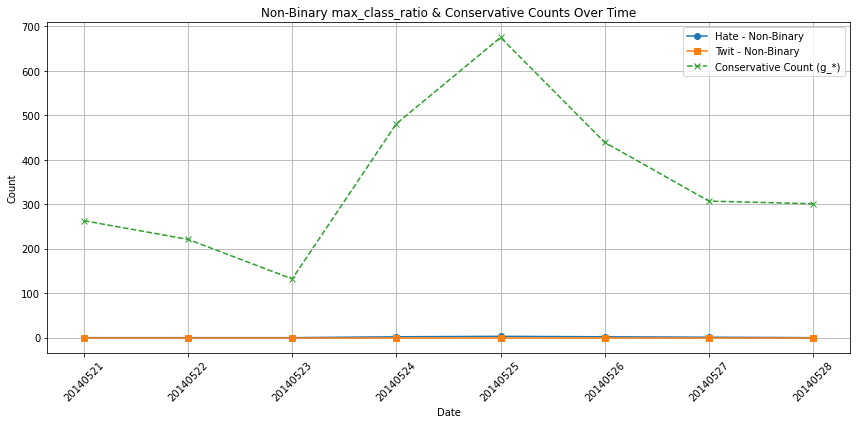

In [45]:
plot_non_binary_and_conservative_counts(
    hate_dfs=[hate_20140521, hate_20140522, hate_20140523, hate_20140524, hate_20140525, hate_20140526, hate_20140527, hate_20140528],
    hate_names=["hate_20140521", "hate_20140522", "hate_20140523", "hate_20140524", "hate_20140525", "hate_20140526", "hate_20140527", "hate_20140528"],
    twit_dfs=[twit_20140521, twit_20140522, twit_20140523, twit_20140524, twit_20140525, twit_20140526, twit_20140527, twit_20140528],
    twit_names=["twit_20140521", "twit_20140522", "twit_20140523", "twit_20140524", "twit_20140525", "twit_20140526", "twit_20140527", "twit_20140528"],
    g_dfs=[g_20140521, g_20140522, g_20140523, g_20140524, g_20140525, g_20140526, g_20140527, g_20140528],
    g_names=["g_20140521", "g_20140522", "g_20140523", "g_20140524", "g_20140525", "g_20140526", "g_20140527", "g_20140528"]
)

In [ ]:
  fb_dfs=[fb_20140521, fb_20140522, fb_20140523, fb_20140524, fb_20140525, fb_20140526, fb_20140527, fb_20140528],
    fb_names=["fb_20140521", "fb_20140522", "fb_20140523", "fb_20140524", "fb_20140525", "fb_20140526", "fb_20140527", "fb_20140528"],

In [ ]:
d_list = [
    d_20170808, d_20170809, d_20170810, d_20170811,
    d_20170812, d_20170813, d_20170814, d_20170815
]

d_names = [
    "d_20170808", "d_20170809", "d_20170810", "d_20170811",
    "d_20170812", "d_20170813", "d_20170814", "d_20170815"
]

g_list = [
    g_20170808, g_20170809, g_20170810, g_20170811,
    g_20170812, g_20170813, g_20170814, g_20170815
]

g_names = [
    "g_20170808", "g_20170809", "g_20170810", "g_20170811",
    "g_20170812", "g_20170813", "g_20170814", "g_20170815"
]

goosed_df = [add_hurtlex_columns(df)for df in g_list]

plot_df_lengths_with_conservative(d_list, d_names, g_list, g_names)


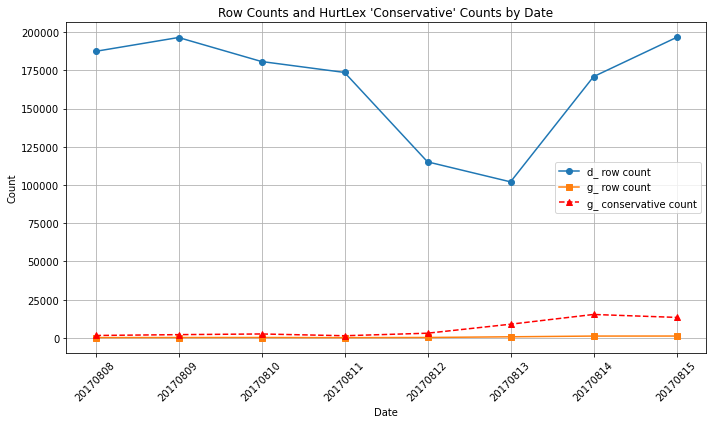

In [61]:
plot_df_lengths_with_conservative(d_list, d_names, g_list, g_names)

In [5]:
nela = nela.sort_values(by='date_published')

In [ ]:
date_frequency = nela['date_published'].value_counts()

2020-06-11 00:00:00    13
2022-02-06 00:00:00    13
2021-11-24 00:00:00    12
2018-11-27 00:00:00    12
2022-09-28 00:00:00    12
                       ..
2024-06-05 20:15:28     1
2024-06-05 20:09:51     1
2024-06-05 01:07:57     1
2024-06-04 23:00:43     1
2025-12-31 00:00:00     1
Name: date_published, Length: 3813, dtype: int64


In [8]:
date_frequency

2020-06-11 00:00:00    13
2022-02-06 00:00:00    13
2021-11-24 00:00:00    12
2018-11-27 00:00:00    12
2022-09-28 00:00:00    12
                       ..
2024-06-05 20:15:28     1
2024-06-05 20:09:51     1
2024-06-05 01:07:57     1
2024-06-04 23:00:43     1
2025-12-31 00:00:00     1
Name: date_published, Length: 3813, dtype: int64

In [12]:
nela

,id,article_id,domain,summary,tags,title,title_md5,content,content_md5,source_id,feed_id,url,author,date_string,date_published,date_collected,collection_name,ipaddr,filemerge_id,raw_html
6738,5058621,truepundit--2018-01-27--Eminem’s Obsession Wit...,truepundit.com,NaN,[],"Eminem’s Obsession With Trump Continues, Says ...",e7f40ff6162b0d4191875e1830765f98,Rapper Eminem’s obsession with bashing Preside...,0d2d8a56a23adfb1a3898322fba01ebb,328,436,https://truepundit.com/eminems-obsession-trump...,NaN,2018-01-27,2018-01-27 00:00:00,2024-06-20 09:02:15,nela-eng,104.21.35.174,777,"<div class=""post-content entry-content cf"" dat..."
7363,5319253,theguardian--2018-01-31--Train carrying US Rep...,www.theguardian.com,NaN,[],Train carrying US Republican lawmakers slams i...,32027d176fa9641fd8bd29bd6f55effb,At least one person was reportedly killed when...,45e4c7734083d60103361d89b6054044,58,436,https://www.theguardian.com/us-news/video/2018...,NaN,2018-01-31,2018-01-31 00:00:00,2024-06-22 14:18:37,nela-eng,199.232.37.111,777,"<div class="" dcr-6j4mrh"" gravityScore=""30"" gra..."
5499,5338975,salon--2018-02-06--Trump co-opts black NFL pla...,www.salon.com,NaN,"['Nfl', 'Donald Trump', 'Drunk Driving', 'Edwi...",Trump co-opts black NFL player’s death to forw...,a04874381670ebb7e21b041358e2e7c8,President Donald Trump referenced the Sunday d...,223707fca29a52ffb4b390b2a852efe8,290,436,https://www.salon.com/2018/02/06/trump-co-opts...,NaN,2018-02-06,2018-02-06 00:00:00,2024-06-22 18:25:17,nela-eng,13.35.93.46,777,"<article class=""article-content"" gravityScore=..."
9829,5320789,breitbart--2018-02-06--‘DACA Fix’: High-Skille...,www.breitbart.com,NaN,"['Republican Hindu Coalition', 'Donald Trump',...",‘DACA Fix’: High-Skilled Indian Workers Rally ...,6c9ef4e3413f6c5f10e20b6f04651581,"WASHINGTON, DC — Hundreds of high-skilled Indi...",b2eab4e268a3cde0a42052b41c0e062d,1,436,http://www.breitbart.com/big-government/2018/0...,NaN,2018-02-06,2018-02-06 00:00:00,2024-06-22 15:05:21,nela-eng,34.117.28.18,777,"<div class=""entry-content"" gravityScore=""342"" ..."
8677,5213779,redstate--2018-02-07--Watch: Canadian Wounded ...,redstate.com,NaN,"['CANADA', 'TERRORISTS', 'AFGHANISTAN', 'JUSTI...",Watch: Canadian Wounded Warrior Grills Trudeau...,5ccf58f3dba9af164816dafcd13df5be,If you want to see the true plight of veterans...,a599e2575b8e7b06c55803af42c32f6a,39,436,https://www.redstate.com/brandon_morse/2018/02...,NaN,2018-02-07,2018-02-07 00:00:00,2024-06-21 17:00:20,nela-eng,104.18.16.211,777,"<section class=""post-body"" gravityScore=""326"" ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4404,6078097,www.theepochtimes.com--2025-07-23--Senate Adva...,www.theepochtimes.com,<p>This article was originally published &#160...,['Politics'],Senate Advances Trump’s $9 Billion Spending Cu...,992c51381def700d867433fc5a376fb3,This article was originally published by The E...,1ddaffed01f90ee7475b01d0da80d43a,97,102,https://thepoliticalinsider.com/senate-advance...,NaN,"Wed, 23 Jul 2025 12:53:14 +0000",2025-07-23 12:53:14,2025-07-24 00:20:56,nela-eng,104.17.158.22,848,"<div class=""article-content"" gravityScore=""530..."
5273,6075712,citizenfreepress.com--2025-07-23--Google beats...,citizenfreepress.com,NaN,[],Google beats the number.,e16a4189d523f21b65b5a9912ca95b42,Post was not sent - check your email addresses...,75b968164672c1d7e185be27d8468933,224,243,https://citizenfreepress.com/breaking/google-b...,NaN,"Wed, 23 Jul 2025 18:48:54 +0000",2025-07-23 18:48:54,2025-07-24 00:08:31,nela-eng,172.67.73.178,848,"<form action=""/breaking/google-beats-the-numbe..."
7633,6075988,www.thesun.co.uk--2025-07-23--Shop-bought heal...,www.thesun.co.uk,NaN,"['prostate health', 'Coronavirus', 'menopause'...","Shop-bought health tests not fit for purpose, ...",7cf8bb87fe3a56a4739559e4f77bb6de,The self-test market is booming in Britain\n\n...,810aea3684a35cd4f8fa5306dc02f362,221,239,https://www.thesun.co.uk/health/35982830/shop-...,NaN,"We

In [22]:
d_20220928

,GlobalEventID,date,Year,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,...,Actor2Geo_CountryCode,ActionGeo_Type,ActionGeo_Fullname,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1065036802,20210928,2021,1,40,40,4,1,1.0,1,...,US,3,"Long Hill, New Jersey, United States",US,USNJ,40.7079,-74.4296,877912,20220928,https://www.newjerseyhills.com/echoes-sentinel...
1,1065036803,20210928,2021,1,40,40,4,1,1.0,5,...,NaN,3,"Long Hill, New Jersey, United States",US,USNJ,40.7079,-74.4296,877912,20220928,https://www.newjerseyhills.com/echoes-sentinel...
2,1065036804,20210928,2021,1,180,180,18,4,-9.0,10,...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,20220928,https://triblive.com/local/westmoreland/jeanne...
3,1065036805,20210928,2021,0,173,173,17,4,-5.0,2,...,NaN,3,"Le Sueur County, Minnesota, United States",US,USMN,44.3833,-93.7336,659485,20220928,https://y105fm.com/southern-minnesota-man-admi...
4,1065036806,20210928,2021,1,15,15,1,1,0.0,2,...,NaN,3,"Le Center, Minnesota, United States",US,USMN,44.3894,-93.7302,646552,20220928,https://y105fm.com/southern-minnesota-man-admi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113322,1065209163,20220928,2022,1,100,100,10,3,-5.0,2,...,MX,1,Mexico,MX,MX,23.0000,-102.0000,MX,20220928,https://www.wbap.com/2022/09/28/quinnipiac-rel...
113323,1065209164,20220928,2022,0,20,20,2,1,3.0,2,...,NaN,4,"Nam-Com, YêBáVM, Vietnam, Republic Of",VM,VM70,21.7167,104.3670,-3722598,20220928,https://www.rep-am.com/life-arts/entertainment...
113324,1065209165,20220928,2022,1,51,51,5,1,3.4,6,...,NaN,1,Canada,CA,CA,60.0000,-96.0000,CA,20220928,https://regina.ctvnews.ca/here-s-where-you-can...
113325,1065209166,20220928,2022,0,120,120,12,3,-4.0,6,...,NaN,1,China,CH,CH,35.0000,105.0000,CH,20220928,https://www.riverfronttimes.com/best-of/2022/f...
